# Deep Sets inclusion rule default (Issue #121)

This notebook replaces the prior markdown note and captures:

- inclusion-rule comparison setup
- default-rule rationale
- fixture and cohort summary loading from known paths
- programmatic visual comparison
- reproducibility guidance when summaries are missing


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython

In [2]:
REPO_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "analysis"
    else Path.cwd().resolve()
)
FIXTURE_SUMMARY = (
    REPO_ROOT / "experiments" / "issue121_fixture_build" / "inclusion_rule_summary.csv"
)
COHORT_SUMMARY = (
    REPO_ROOT
    / "experiments"
    / "issue121_inclusion_compare"
    / "inclusion_rule_summary.csv"
)

REGEN_COMMAND_STRINGS = {
    "fixture": "PYTHONPATH=. python build_deepsets_dataset.py --config configs/deepsets_issue121_fixture.yaml --output-dir experiments/issue121_fixture_build --num-shards 1 --shard-index 0",
    "cohort": "MODE=build CONFIG=configs/deepsets_ispy2.yaml OUT_ROOT=experiments/issue121_inclusion_compare NUM_SHARDS=1 SLURM_ARRAY_TASK_ID=0 sbatch slurm/deepsets_job.slurm",
}


print(f"Repository root: {REPO_ROOT}")
print(f"Fixture summary exists: {FIXTURE_SUMMARY.exists()} -> {FIXTURE_SUMMARY}")
print(f"Cohort summary exists:  {COHORT_SUMMARY.exists()} -> {COHORT_SUMMARY}")

Repository root: /home/lunad/vanguard-issue121
Fixture summary exists: True -> /home/lunad/vanguard-issue121/experiments/issue121_fixture_build/inclusion_rule_summary.csv
Cohort summary exists:  False -> /home/lunad/vanguard-issue121/experiments/issue121_inclusion_compare/inclusion_rule_summary.csv


In [7]:
ALLOW_REGEN = os.getenv("ISSUE121_ALLOW_REGEN", "0") == "1"


def load_summary(summary_path: Path, key: str) -> pd.DataFrame | None:
    """Load a summary CSV or print exact regenerate guidance."""
    if summary_path.exists():
        return pd.read_csv(summary_path)

    print(f"Missing summary CSV: {summary_path}")
    print("Regenerate with:")
    print(REGEN_COMMAND_STRINGS[key])

    if ALLOW_REGEN:
        print("ISSUE121_ALLOW_REGEN=1 detected; running regenerate command now...")
        ipy = get_ipython()
        if ipy is None:
            print(
                "No active IPython kernel; copy/paste the regenerate command manually."
            )
        else:
            previous_cwd = Path.cwd()
            os.chdir(REPO_ROOT)
            try:
                ipy.system(REGEN_COMMAND_STRINGS[key])
            finally:
                os.chdir(previous_cwd)
        if summary_path.exists():
            return pd.read_csv(summary_path)
        print(f"Still missing after attempted regenerate: {summary_path}")
    else:
        print(
            "Set ISSUE121_ALLOW_REGEN=1 to allow optional command execution from this notebook."
        )

    return None


fixture_df = load_summary(FIXTURE_SUMMARY, "fixture")
cohort_df = load_summary(COHORT_SUMMARY, "cohort")

## Default rule and rationale

**Default:** `local_radius_with_fallback`

Rationale:

- Preserves existing production behavior while alternatives remain measurable.
- Keeps tumor-local inclusion as the first criterion.
- Prevents case drops when no points satisfy local-radius filtering.
- Uses bounded nearest-64 fallback only when needed.


In [8]:
display_cols = [
    "inclusion_rule",
    "cases_written",
    "cases_skipped",
    "fallback_fraction",
    "num_points_median",
    "num_points_range",
]

if fixture_df is not None:
    print("Fixture comparison")
    display(fixture_df[display_cols])

if cohort_df is not None:
    print("Cohort comparison")
    display(cohort_df[display_cols])

Fixture comparison


,inclusion_rule,cases_written,cases_skipped,fallback_fraction,num_points_median,num_points_range
0,local_radius_with_fallback,4,0,0.5,1.5,1-3
1,local_radius_only,2,2,0.0,1.0,1-1
2,nearest_64_only,4,0,0.0,2.0,1-3


Cohort comparison


,inclusion_rule,cases_written,cases_skipped,fallback_fraction,num_points_median,num_points_range
0,local_radius_with_fallback,980,0,0.044898,517.5,1-3537
1,local_radius_only,936,44,0.000000,547.5,1-3537
2,nearest_64_only,980,0,0.000000,64.0,13-64


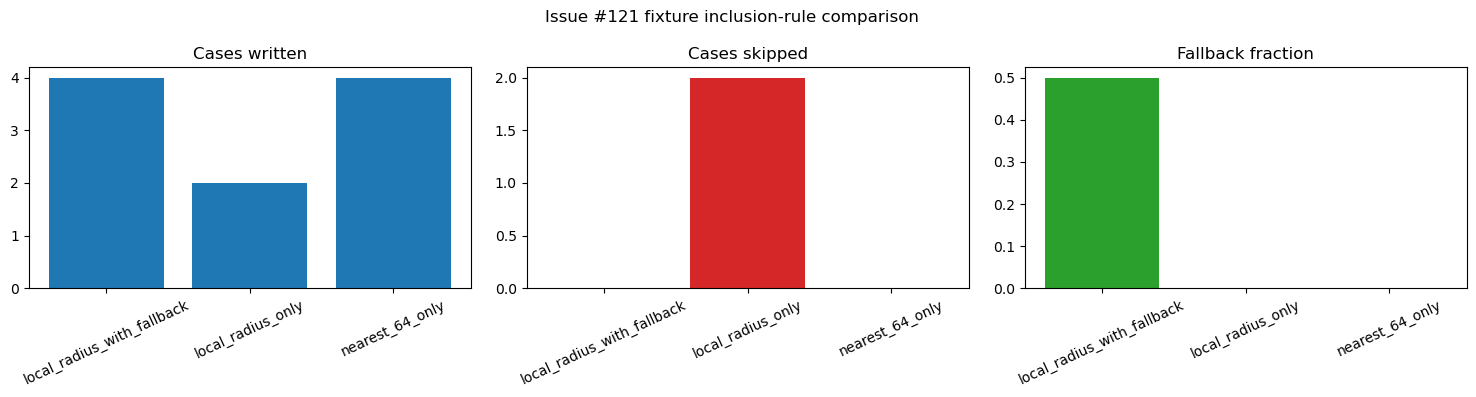

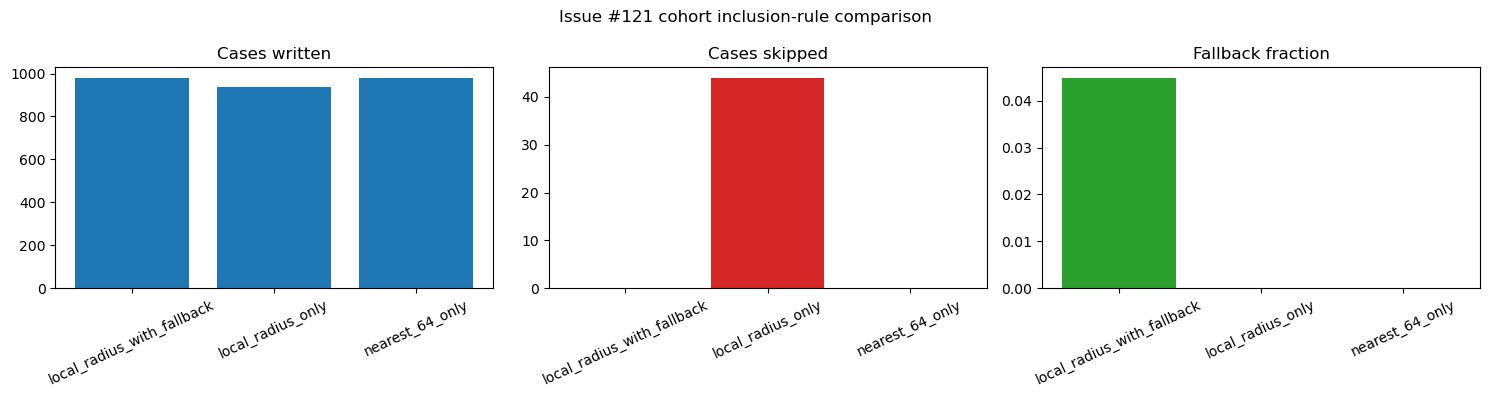

In [9]:
def plot_summary(df: pd.DataFrame, title: str) -> None:
    """Plot inclusion-rule comparison bars for a summary table."""
    plot_df = df.copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(plot_df["inclusion_rule"], plot_df["cases_written"], color="#1f77b4")
    axes[0].set_title("Cases written")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(plot_df["inclusion_rule"], plot_df["cases_skipped"], color="#d62728")
    axes[1].set_title("Cases skipped")
    axes[1].tick_params(axis="x", rotation=25)

    axes[2].bar(
        plot_df["inclusion_rule"], plot_df["fallback_fraction"], color="#2ca02c"
    )
    axes[2].set_title("Fallback fraction")
    axes[2].tick_params(axis="x", rotation=25)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


if fixture_df is not None:
    plot_summary(fixture_df, "Issue #121 fixture inclusion-rule comparison")

if cohort_df is not None:
    plot_summary(cohort_df, "Issue #121 cohort inclusion-rule comparison")

In [10]:
def summarize_default_decision(df: pd.DataFrame, dataset_name: str) -> None:
    """Print a compact rationale check for the default rule."""
    cols = [
        "inclusion_rule",
        "cases_written",
        "cases_skipped",
        "fallback_fraction",
        "num_points_median",
    ]
    table = df[cols].set_index("inclusion_rule")
    print(f"\n{dataset_name} decision check")
    print(table)

    local_only_skips = table.loc["local_radius_only", "cases_skipped"]
    default_skips = table.loc["local_radius_with_fallback", "cases_skipped"]
    default_fallback = table.loc["local_radius_with_fallback", "fallback_fraction"]

    print(
        "Rationale check: local_radius_with_fallback retains tumor-local filtering, "
        f"avoids case drops ({default_skips} skipped vs {local_only_skips} for local_radius_only), "
        f"and uses fallback sparingly (fraction={default_fallback})."
    )


if fixture_df is not None:
    summarize_default_decision(fixture_df, "Fixture")

if cohort_df is not None:
    summarize_default_decision(cohort_df, "Cohort")


Fixture decision check
                            cases_written  cases_skipped  fallback_fraction  \
inclusion_rule                                                                
local_radius_with_fallback              4              0                0.5   
local_radius_only                       2              2                0.0   
nearest_64_only                         4              0                0.0   

                            num_points_median  
inclusion_rule                                 
local_radius_with_fallback                1.5  
local_radius_only                         1.0  
nearest_64_only                           2.0  
Rationale check: local_radius_with_fallback retains tumor-local filtering, avoids case drops (0 skipped vs 2 for local_radius_only), and uses fallback sparingly (fraction=0.5).

Cohort decision check
                            cases_written  cases_skipped  fallback_fraction  \
inclusion_rule                                               